## Introduction

The objective of this notebook is to **compare several simple long-only investment strategies:**
1. Equity buy-and-hold
2. Equity–bond buy-and-hold
3. Volatility-driven equity-to-bond switching
4. Drawdown-driven equity-to-bond switching
5. Drawdown-driven & volatility-driven equity-to-bond switching

## Import librairies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

## Custom function

In [3]:
def compute_metrics(price_ts, title):

    dd = price_ts / price_ts.expanding().max() - 1
    max_dd = dd.min()
    print(f'max drawdown: {max_dd:.2%}')
    
    win_loss_ratio = price_ts.diff().clip(lower=0).sum() / -price_ts.diff().clip(upper=0).sum()
    print(f'win/loss ratio: {win_loss_ratio:.2f}')

    sharpe = (price_ts.pct_change().mean() * 252) / (price_ts.pct_change().std() * np.sqrt(252))
    print(f'sharpe ratio: {sharpe:.2f}')

    total_performance = price_ts.iloc[-1] / price_ts.iloc[0]
    n = ((price_ts.index[-1]-price_ts.index[0]).days / 365)
    x = total_performance**(1/n) -1
    print(f'annualized return: {x:.2%}')

    annual_returns = price_ts.groupby(price_ts.index.year).last().pct_change()

    multiplier = -0.55 / max_dd
    #multiplier = min([2, multiplier])
    print(f'multiplier: {multiplier:.2f}')
    annual_returns_scaled = annual_returns * multiplier
    x_scaled = annual_returns_scaled.add(1).prod()**(1/n) - 1
    print(f'annualized return scaled: {x_scaled:.2%}')

    plt.figure(figsize=(13, 4))
    sns.lineplot(data=price_ts)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns.index.astype(str), y=annual_returns.values)
    plt.title(f'Annual Returns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns_scaled.index.astype(str), y=annual_returns_scaled.values)
    plt.title(f'Annual Returns Scaled')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

## Inputs

In [4]:
eq_asset = 'SPY'
bond_asset = 'IBGS.MI'
vol_threshold_buy = 0.8
vol_threshold_sell = 0.04
vol_window = 5
dd_threshold_buy = 0.60
dd_threshold_sell = 1.0


## Script

In [5]:
df_eq = pd.read_csv(f'data/{eq_asset}.csv', index_col=0, parse_dates=True)
df_bond = pd.read_csv(f'data/{bond_asset}.csv', index_col=0, parse_dates=True)
df_bond = df_eq * 0 + 0.0/365
df_bond = df_bond.add(1).cumprod()
df_price = pd.concat([df_eq.price, df_bond.price], axis=1, keys=['equity', 'bond']).dropna()


In [6]:
df_eq = df_eq.loc['2007':]

/var/folders/5g/b4bpmvtn7tjcmrg4l2k_p_9r0000gn/T/ipykernel_37202/3757240221.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_eq['price'].rolling(250*2).apply(lambda x: x[-1]/x[0]-1).plot()


<Axes: >

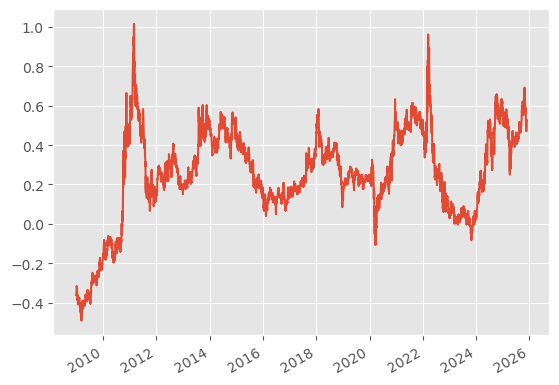

In [11]:
df_eq['price'].rolling(250*2).apply(lambda x: x[-1]/x[0]-1).plot()

In [10]:
df_eq['price'].rolling(250).apply(lambda x: x[-1]/x[0]-1).describe()

/var/folders/5g/b4bpmvtn7tjcmrg4l2k_p_9r0000gn/T/ipykernel_37202/261771007.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_eq['price'].rolling(250).apply(lambda x: x[-1]/x[0]-1).describe()


count    4509.000000
mean        0.116319
std         0.168272
min        -0.469021
25%         0.038866
50%         0.144380
75%         0.212643
max         0.778244
Name: price, dtype: float64

In [35]:
((df_eq/df_eq.expanding().max())-1).min()

price   -0.551894
dtype: float64

,price
2008-01-02,103.778236
2008-01-03,103.728157
2008-01-04,101.186150
2008-01-07,101.100204
2008-01-08,99.467606
...,...
2025-11-21,657.088379
2025-11-24,666.759766
2025-11-25,673.031250
2025-11-26,677.677551


## 1. Equity buy-and-hold

max drawdown: -55.19%
win/loss ratio: 1.13
sharpe ratio: 0.52
annualized return: 8.45%
multiplier: 1.00
annualized return scaled: 7.68%


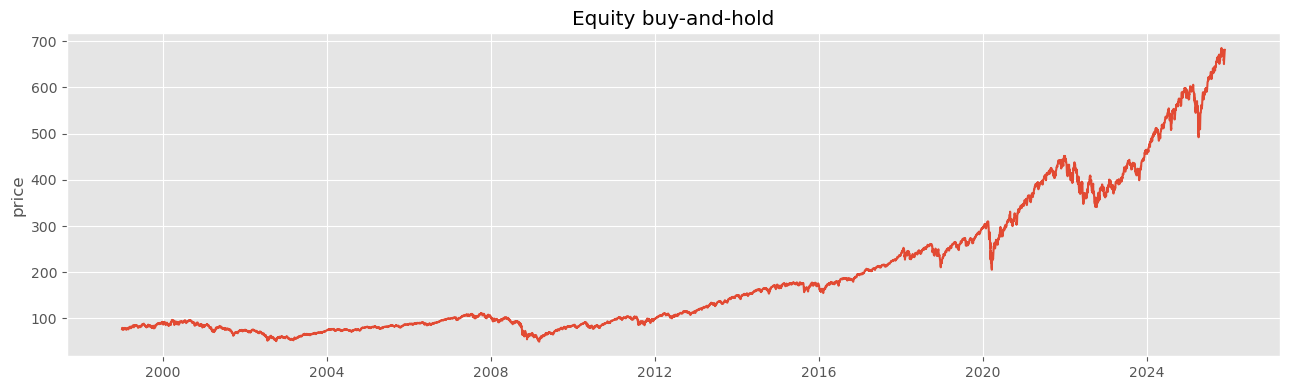

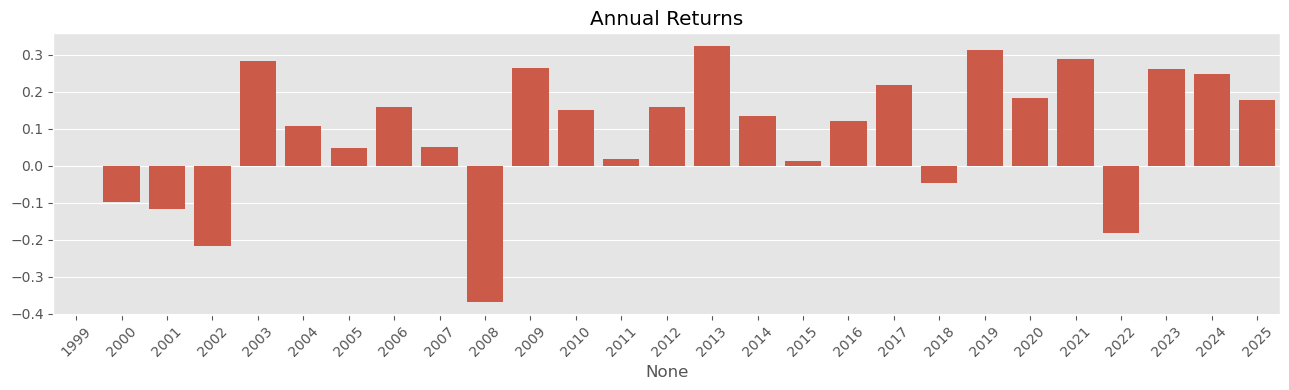

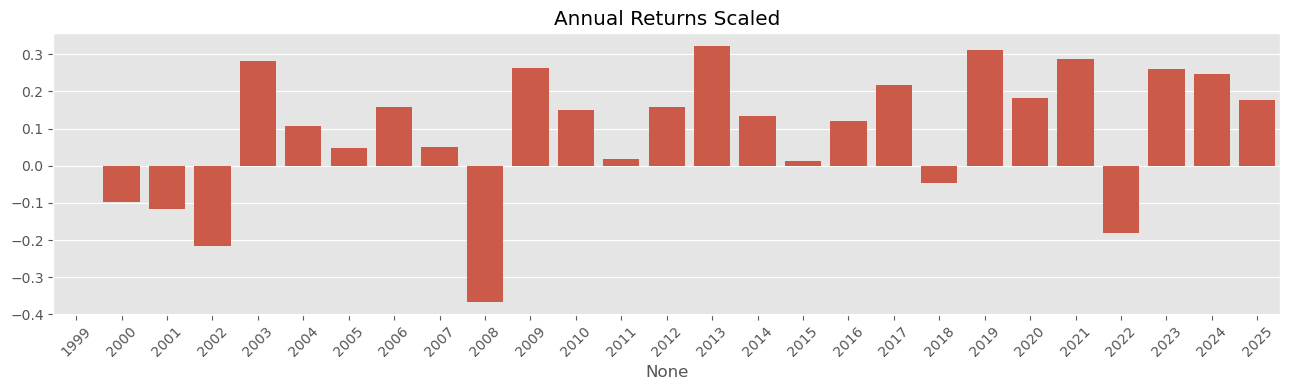

In [5]:
compute_metrics(df_eq.price, 'Equity buy-and-hold')

## 2. Equity–bond buy-and-hold

## 3. Volatility-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.27
sharpe ratio: 0.35
annualized return: 3.33%
multiplier: 1.71
annualized return scaled: 5.41%


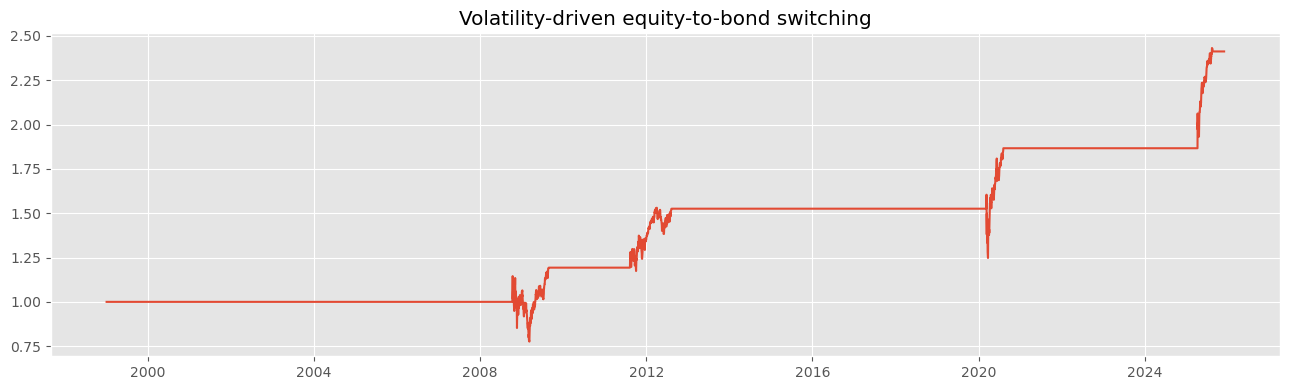

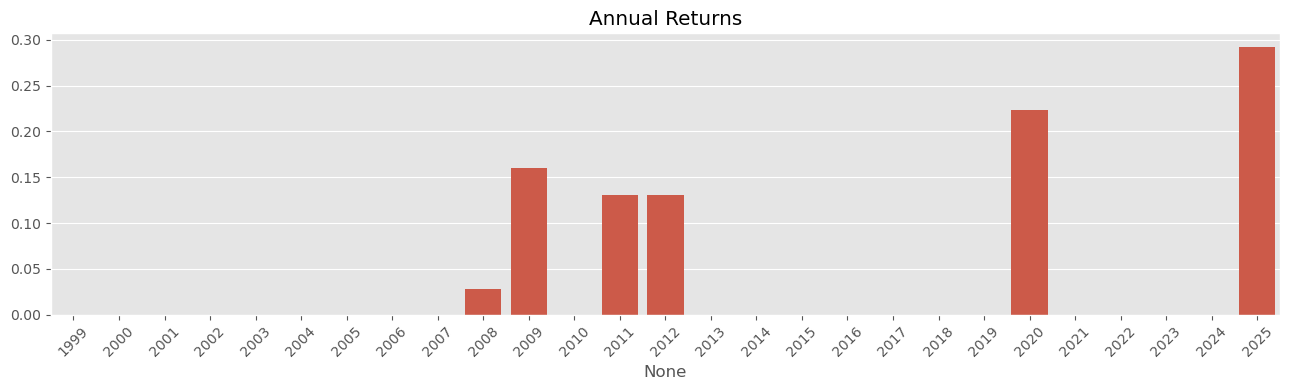

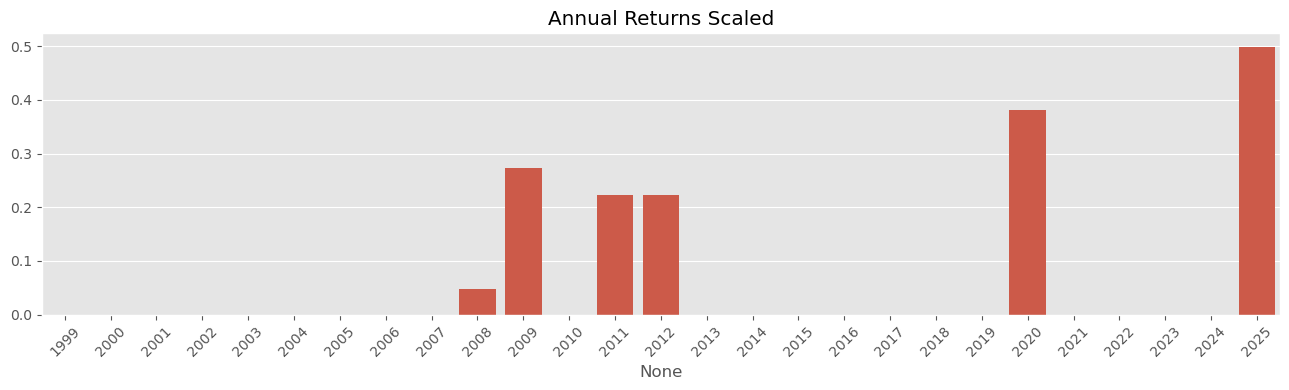

In [6]:
df_vol = df_price.pct_change().rolling(window=vol_window).std() * np.sqrt(252)
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[df_vol.equity > vol_threshold_buy, 'equity'] = 1
df_signal.loc[df_vol.equity < vol_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Volatility-driven equity-to-bond switching')

## 4. Drawdown-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.12
sharpe ratio: 0.35
annualized return: 3.58%
multiplier: 1.71
annualized return scaled: 5.80%


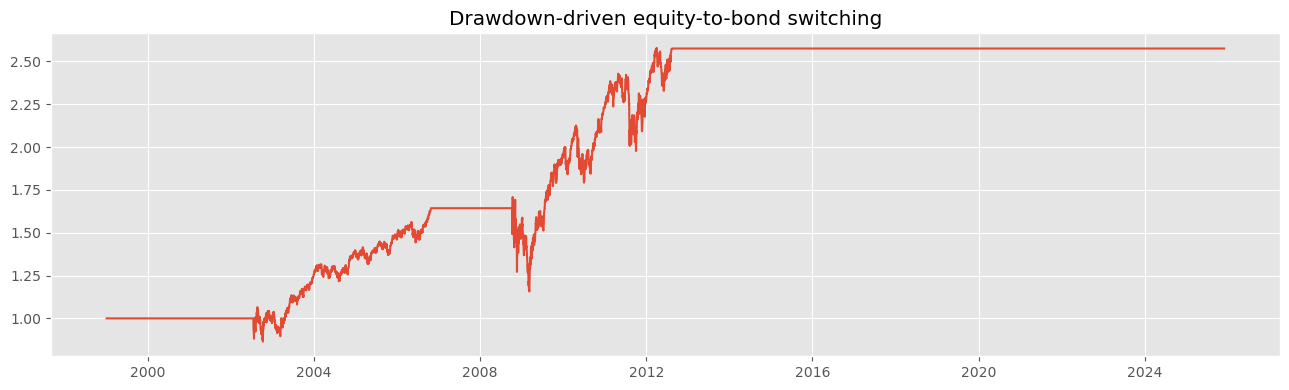

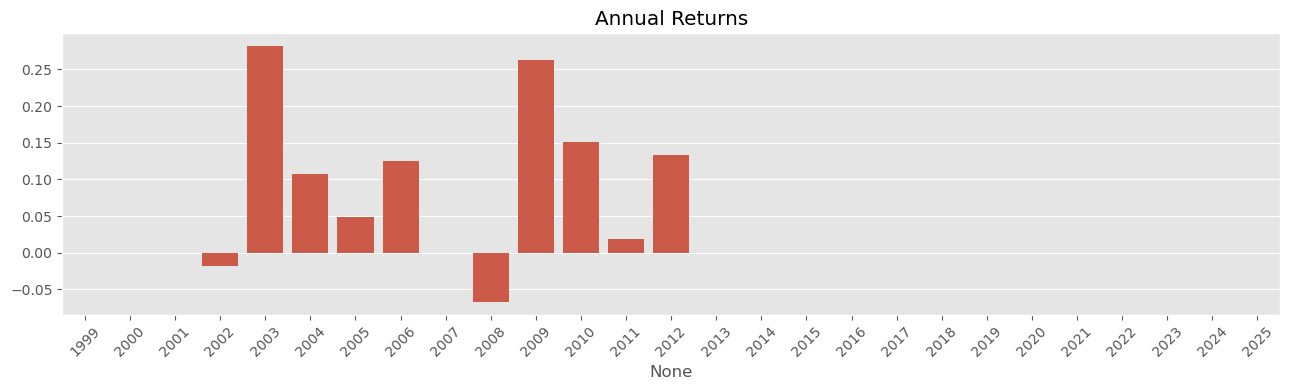

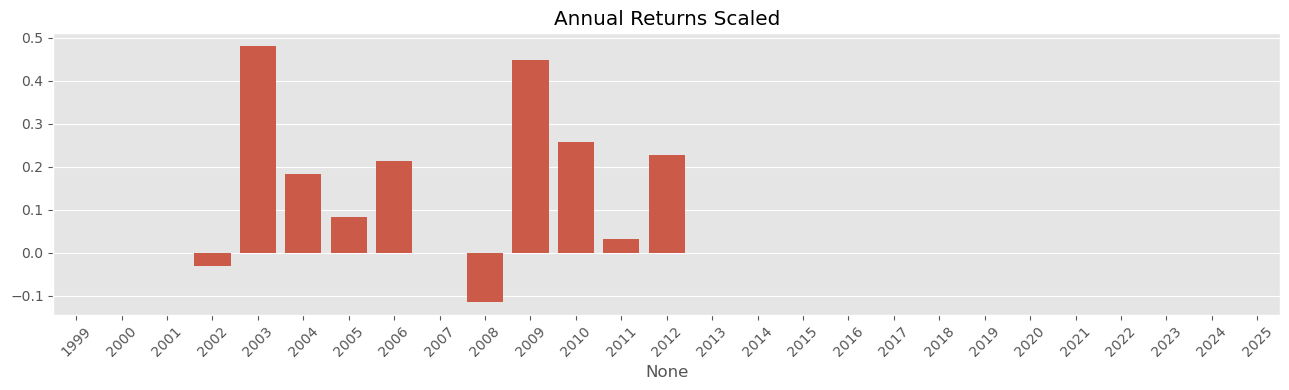

In [7]:
dd = df_price.equity / df_price.equity.expanding().max()
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[dd < dd_threshold_buy, 'equity'] = 1
df_signal.loc[dd >= dd_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Drawdown-driven equity-to-bond switching')

## 5. Drawdown-driven & volatility-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.18
sharpe ratio: 0.44
annualized return: 5.18%
multiplier: 1.71
annualized return scaled: 8.42%


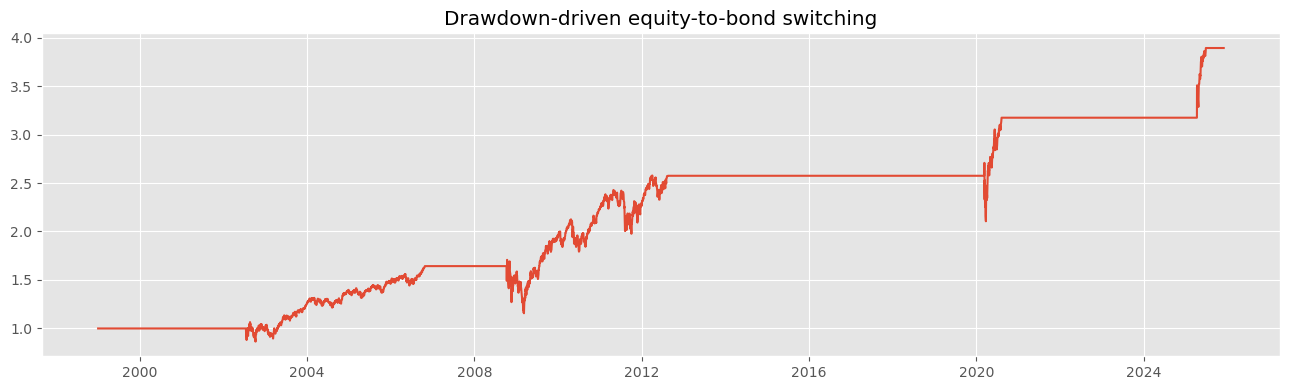

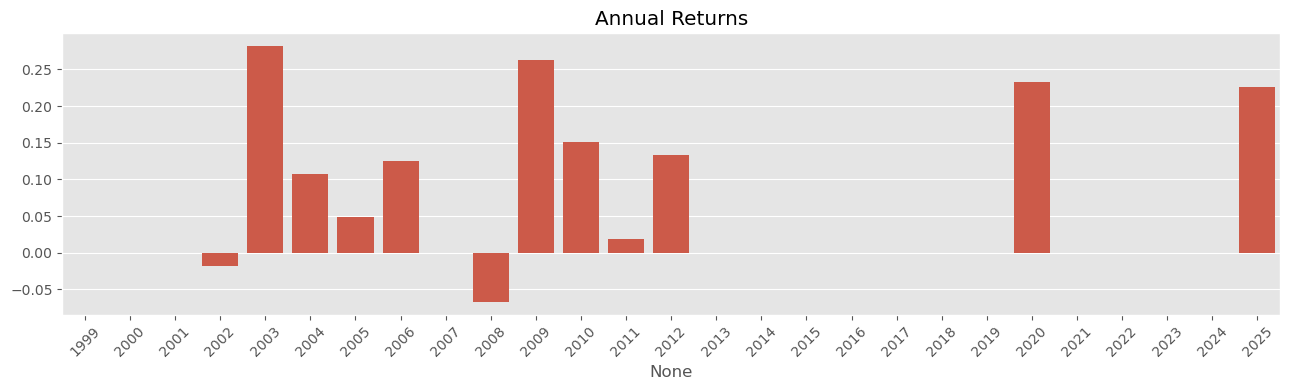

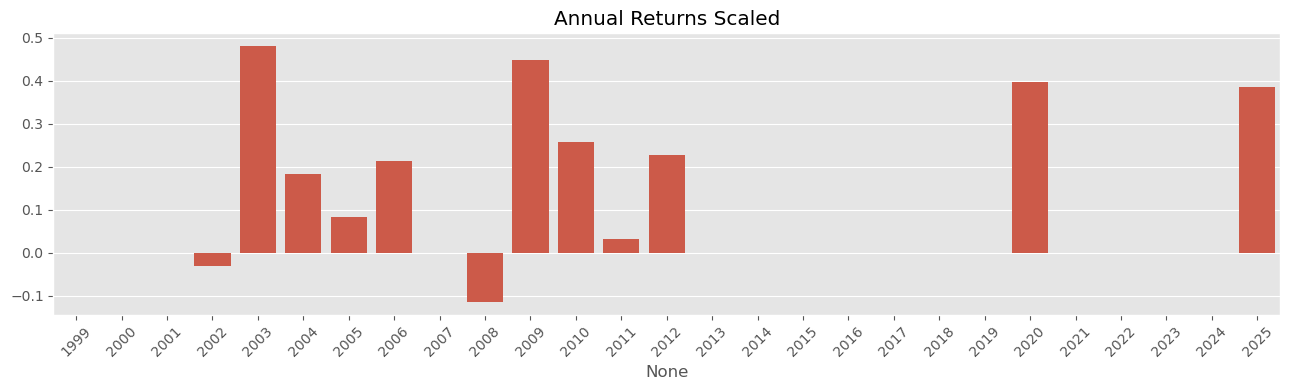

In [8]:
dd = df_price.equity / df_price.equity.expanding().max()
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[df_vol.equity > vol_threshold_buy, 'equity'] = 1
df_signal.loc[dd < dd_threshold_buy, 'equity'] = 1
df_signal.loc[dd >= dd_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Drawdown-driven equity-to-bond switching')